In [287]:
import torch
from utils import solve_riccati
import numpy as np
from network import PhiNetwork, ScoreNetwork
from utils import batched_jacobian
import matplotlib.pyplot as plt

In [288]:
phi_net = ScoreNetwork(input_dim=1+1, out_dim=1, hidden_dim=64, num_blocks=4)
phi_net.load_state_dict(torch.load('network/phi_network_diff_bsde_timesteps50_kf10_v2.pth'))

/var/folders/pd/hp6m3j2j5v9bd6w64h7wl3rm0000gn/T/ipykernel_13254/3406949880.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  phi_net.load_state_dict(torch.load('network/p

<All keys matched successfully>

In [289]:
T = 1.0  # End time
n = 1    # Dimension of state space
m = 1    # Dimension of Brownian motion
N = 10000 # Number of training samples
dt = 0.02
steps = int(T/dt)
noise_level = 2

In [290]:
score_nn = ScoreNetwork(input_dim=n+1, out_dim=n, hidden_dim=32, num_blocks=2)
score_nn.load_state_dict(torch.load(f'network/toy_score_network.pth'))

/var/folders/pd/hp6m3j2j5v9bd6w64h7wl3rm0000gn/T/ipykernel_13254/3287013246.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  score_nn.load_state_dict(torch.load(f'network

<All keys matched successfully>

In [291]:
def f(x, t):
    ##TODO: maybe change t to T-t##
    """
    Drift function of X_t for a nonlinear system.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
        t (torch.Tensor): torch.tensor of shape (1,): Current time
    Returns:
        torch.Tensor: Drift vector. Shape (N, n)
    """
    a = 2
    df = a * x + noise_level**2 * score_nn(x, (T - t).repeat(x.shape[0], 1))
    return df


def g(x):
    """
    Diffusion function of X_t for a nonlinear system.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
    Returns:
        torch.Tensor: Diffusion matrix. Shape (N, n, m)
    """
    B = torch.tensor([[1.0]]) * noise_level
    B = B.unsqueeze(0).repeat(x.shape[0], 1, 1)
    return B

def lf(x):
    """
    Terminal cost function for a linear system.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
    Returns:
        torch.Tensor: Terminal cost. Shape (N,)
    """
    return 0.5 *(x - 3.0)**2

In [292]:
from utils import rollout, noise

In [ ]:
theta0 = torch.randn((N, n))

# theta_auto = theta0.clone().detach().requires_grad_(True)
theta_phi  = theta0.clone().detach().requires_grad_(True)  # requires_grad can stay True; we won't call backward()

# opt_auto = torch.optim.Adam([theta_auto], lr=1e-3)
opt_phi  = torch.optim.Adam([theta_phi],  lr=1e-3)

# loss_hist_auto = []
loss_hist_phi  = []
# theta_hist_auto = []
theta_hist_phi  = []
# theta_hist_auto.append(theta_auto.detach().clone())
theta_hist_phi.append(theta_phi.detach().clone())
for i in range(10000):
    W_f = torch.randn(steps + 1, N, m) * torch.sqrt(torch.tensor(dt))
    # ======== Method A: autograd ========
    # opt_auto.zero_grad(set_to_none=True)

    # # compute loss (keep exactly same code path)
    # xT_auto = rollout(f, g, T, dt, theta_auto, W_f)[-1]
    # loss_auto = lf(xT_auto).sum(dim=0)  # your original loss
    # mean_auto = theta_auto.mean(dim=0, keepdim=True)  # scalar for backward 
    # temp_auto = theta_auto - mean_auto.repeat(theta_auto.shape[0], 1)  # shape (N,)
    # var_auto = (temp_auto.T @ temp_auto) / (N - 1)  # scalar variance
    # var_auto_inv = 1.0 / (var_auto + 1e-6*torch.eye(1))  # scalar inverse variance
    # kl_auto = 0.5 * (torch.trace(var_auto) + mean_auto @ mean_auto.T - 1 - torch.logdet(var_auto + 1e-6*torch.eye(1)))  # scalar KL divergence
    # loss_auto = loss_auto + kl_auto
    # loss_auto.backward()
    # opt_auto.step()

    # ======== Method B: custom phi gradient ========
    opt_phi.zero_grad(set_to_none=True)

    # compute loss for logging only (optional but useful)
    # If rollout is expensive and you only care about update, you can skip this forward.
    # with torch.no_grad():
    #     xT_phi = rollout(f, g, T, dt, theta_phi, W_f)[-1]
    #     loss_phi = lf(xT_phi).sum(dim=0)

    # apply your gradient estimator
    # IMPORTANT: optimizer expects theta_phi.grad to be a tensor on same device/dtype
    with torch.no_grad():
        ghat_lf = phi_net(theta_phi, torch.tensor(0.0).repeat(theta_phi.shape[0], 1))  # shape (N, n)
        mean_theta = theta_phi.mean(dim=0)  # shape (1, n)
        temp = theta_phi - mean_theta.repeat(theta_phi.shape[0], 1)  # shape (N, n)
        var_theta = ((temp.T @ temp) / (N - 1))  # shape (n, n)
        var_theta_inv = torch.linalg.pinv(var_theta + 1e-6 * torch.eye(n))  # shape (n, n)
        ghat_kl = (-var_theta_inv @ temp.T  + theta_phi.T).T  # shape (N, n)
        # print(ghat_kl.std().item(), ghat_kl.mean().item())
        ghat = ghat_lf + ghat_kl  # shape (N, n)
        theta_phi.grad = ghat.detach()
    opt_phi.step()

    # ---- log ----
    # loss_hist_auto.append(loss_auto.detach().item() if loss_auto.numel()==1 else loss_auto.detach().sum().item())
    # loss_hist_phi.append(loss_phi.detach().item()  if loss_phi.numel()==1  else loss_phi.detach().sum().item())

    # theta_hist_auto.append(theta_auto.detach().clone())
    # theta_hist_phi.append(theta_phi.detach().clone())

    # optional: print occasionally
    # if i % max(1, 500) == 0:
    #     print(f"iteration {i:4d} | autograd loss {loss_hist_auto[-1]:.6g} | phi loss {loss_hist_phi[-1]:.6g}")
    if i % max(1, 500) == 0:
        print(f"iteration {i:4d} | autograd loss {loss_auto.detach().item():.6g}")

    

# ---- final report ----
# print("\nFinal:")
# print(f"autograd: loss={loss_hist_auto[-1]:.6g}")
# print(f"phi     : loss={loss_hist_phi[-1]:.6g}")

# ---- plot ----
# plt.figure()
# plt.plot(loss_hist_auto, label="autograd")
# plt.plot(loss_hist_phi,  label="phi(theta) grad")
# plt.yscale("log")  # often helpful; remove if you prefer linear
# plt.xlabel("step")
# plt.ylabel("loss")
# plt.title("Loss convergence comparison")
# plt.legend()
# plt.grid(True, which="both", linestyle="--", linewidth=0.5)
# plt.show()

iteration    0 | autograd loss 2624.74
iteration  500 | autograd loss 2624.74
iteration 1000 | autograd loss 2624.74
iteration 1500 | autograd loss 2624.74
iteration 2000 | autograd loss 2624.74


Text(0.5, 1.0, 'Optimal theta comparison')

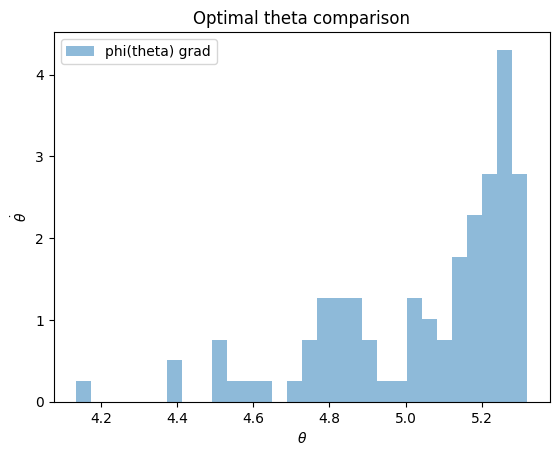

In [ ]:
## plot of optimal theta
plt.figure()
# plt.scatter(theta_auto.detach().numpy()[:,0], theta_auto.detach().numpy()[:,1], label="autograd", alpha=0.5)
plt.hist(theta_phi.detach().numpy()[:,0], bins=30, label="phi(theta) grad", alpha=0.5, density=True)
plt.xlabel(r"$\theta$")
plt.ylabel(r"$\dot{\theta}$")
plt.legend()
plt.title("Optimal theta comparison")

In [ ]:
theta_phi.detach().mean(dim=0), theta_auto.detach().mean(dim=0)

(tensor([5.0469]), tensor([-0.0248]))

In [ ]:
theta_phi.detach().std(dim=0), theta_auto.detach().std(dim=0)

(tensor([0.2549]), tensor([1.0206]))

In [ ]:
randindex = np.random.randint(0, theta_phi.shape[0], size=50) # generate 50 random index
theta_phi.detach()[randindex,0]

tensor([5.2864, 5.2998, 4.9445, 5.2739, 5.1570, 5.2285, 5.1859, 5.2376, 5.2440,
        4.8455, 5.1980, 5.1736, 4.4995, 5.2251, 4.3952, 5.2245, 5.2251, 5.1733,
        5.2245, 4.7531, 5.2925, 5.2397, 5.1736, 5.1733, 4.1350, 5.0715, 4.8455,
        4.8832, 5.2397, 5.1387, 5.2376, 4.8455, 5.1601, 5.1570, 5.2251, 5.2304,
        4.7602, 5.0715, 5.2507, 4.4995, 5.1733, 5.1422, 5.1885, 5.1422, 5.0861,
        5.2435, 5.2998, 4.8455, 5.2245, 5.0857])

In [ ]:
final_traj_phi = rollout(f, g, T, dt, theta_phi, torch.randn(steps + 1, N, m) * torch.sqrt(torch.tensor(dt)))
# compare_traj = rollout(f, g, T, dt, theta_auto, W_f)

In [ ]:
final_traj_phi.shape

torch.Size([51, 100, 1])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


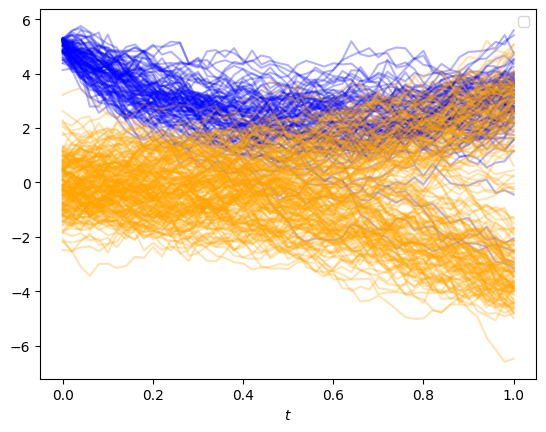

In [ ]:
plt.figure()
plt.plot(np.arange(0,51)*dt, final_traj_phi[:, :200, 0].detach().numpy(), color='blue', alpha=0.3)
plt.plot(np.arange(0,51)*dt, compare_traj[:, :200, 0].detach().numpy(), color='orange', alpha=0.3)
plt.xlabel(r"$t$")
# plt.plot(np.arange(0,51)*dt, final_traj_phi[:, 999, 0].detach().numpy(), color='blue', alpha=1, label='rewarded generative traj')
# plt.plot(np.arange(0,51)*dt, compare_traj[:, 999, 0].detach().numpy(), color='orange', alpha=1, label='original generative traj')
# plt.ylabel(r"$\dot{\theta}$")
# plt.title("Sample trajectories with phi(theta) grad")
plt.legend()
plt.show()

In [ ]:
from utils import generate_initial_data

In [ ]:
INITIAL_DIST = 'Bimodal'  # 'Gaussian' or 'Bimodal'
shift = 3.0
m_0 = torch.tensor([0.0])  # Mean of initial distribution
sigma_0 = torch.eye(n) * 1  # Covariance of initial distribution
X_0 = generate_initial_data(INITIAL_DIST, m_0, sigma_0, N, shift)

In [ ]:
def tilted_pdf(x):
    pdf = (torch.exp(torch.tensor(-9.0)) * torch.exp(-x**2) + torch.exp(-(x-3.0)**2)) / ((1 + torch.exp(torch.tensor(-9.0))) * torch.sqrt(torch.tensor(torch.pi)))
    return pdf

In [ ]:
def original_pdf(x):
    m1 = 3.0
    m2 = -3.0
    sigma = 1.0
    p1 = torch.exp(-0.5 * ((x - m1) / sigma)**2) / (sigma * torch.sqrt(torch.tensor(2.0) * torch.pi))
    p2 = torch.exp(-0.5 * ((x - m2) / sigma)**2) / (sigma * torch.sqrt(torch.tensor(2.0) * torch.pi))
    return 0.5 * (p1 + p2)

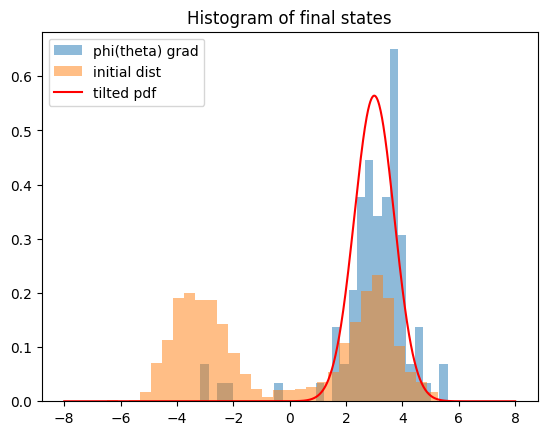

In [ ]:
plt.figure()
plt.hist(final_traj_phi[-1,:,:].detach().numpy(), bins=30, alpha=0.5, label='phi(theta) grad', density=True)
plt.hist(compare_traj[-1,:,:].detach().numpy(), bins=30, alpha=0.5, label='initial dist', density=True)
# plt.hist(final_traj_auto[-1,:,:].detach().numpy(), bins=30, alpha=0.5, label='autograd')
x = torch.linspace(-8, 8, 1000)
plt.plot(x.numpy(), tilted_pdf(x).numpy(), label='tilted pdf', color='red')
plt.legend()
plt.title("Histogram of final states")
plt.show()

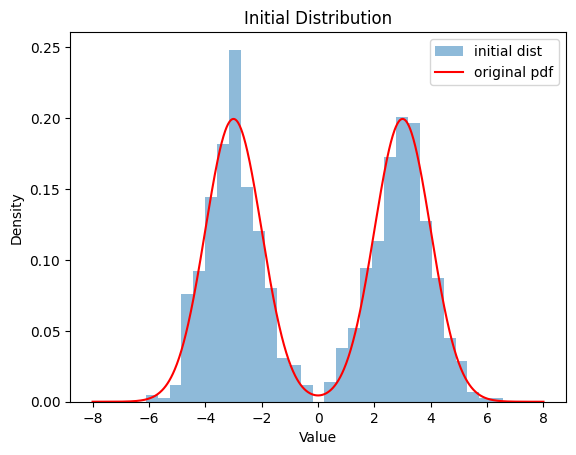

In [ ]:
plt.figure()
plt.hist(X_0.detach().numpy(), bins=30, alpha=0.5, label='initial dist', density=True)
x = torch.linspace(-8, 8, 1000)
plt.plot(x.numpy(), original_pdf(x).numpy(), label='original pdf', color='red')
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Initial Distribution")
plt.legend()
plt.show()